In [9]:
#%matplotlib widget
%load_ext autoreload
%autoreload 2
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, CenteredNorm
from mpl_toolkits.mplot3d import Axes3D
from tqdm.notebook import tqdm
from cx import extrapolation
from cx.fly import *
from cx.plotting import plot_weights, plot_grouped_weights

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Construct extrapolator
kernel_parameters_by_roi = {}
next_index = 0
for roi in ROIS:
    kernel_parameters_by_roi[roi], next_index = extrapolation.build_kernel_parameters(next_index, CELLS, columnar_kernel_size=5, symmetric_epgs=True, epg_width=5, symmetric_delta7=False) #(roi == "PB"))

extrapolator = extrapolation.Extrapolator(ROIS, CELLS, COLUMNS_BY_ROI, PROJECTIONS, kernel_parameters_by_roi, kernel_parameter_count=next_index)
print(extrapolator.theta_len(), "parameters")

cell_labels = CELLS["type"] + "_" + CELLS["subtype"]
grouped_labels = extrapolator.grouped["type"] + "_" + extrapolator.grouped["subtype"]

130 parameters


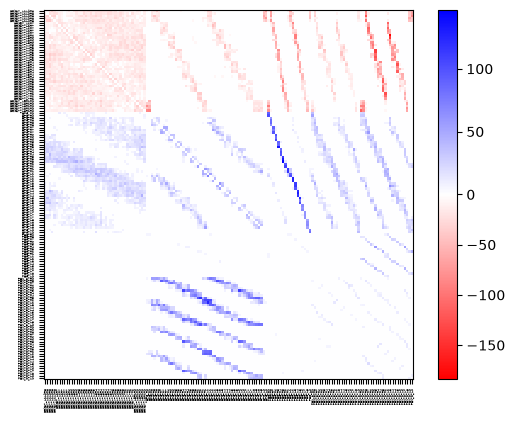

In [3]:
W_ground_signed = W_ground.copy()
W_ground_signed[:,CELLS["type"] == "Delta7",:] *= -1

np.save("data/fly-truth-full.npy", W_ground_signed)
plot_weights(W_ground_signed.sum(0), cell_labels)


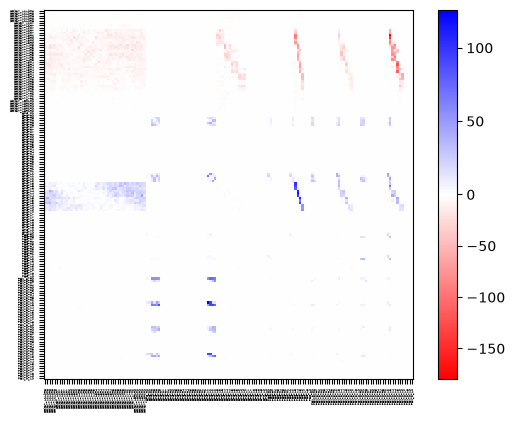

In [4]:
W_sample_signed = W_sample.copy()
W_sample_signed[:,CELLS["type"] == "Delta7",:] *= -1

np.save("data/fly-sample-full.npy", W_sample_signed)
plot_weights(W_sample_signed.sum(0), cell_labels)

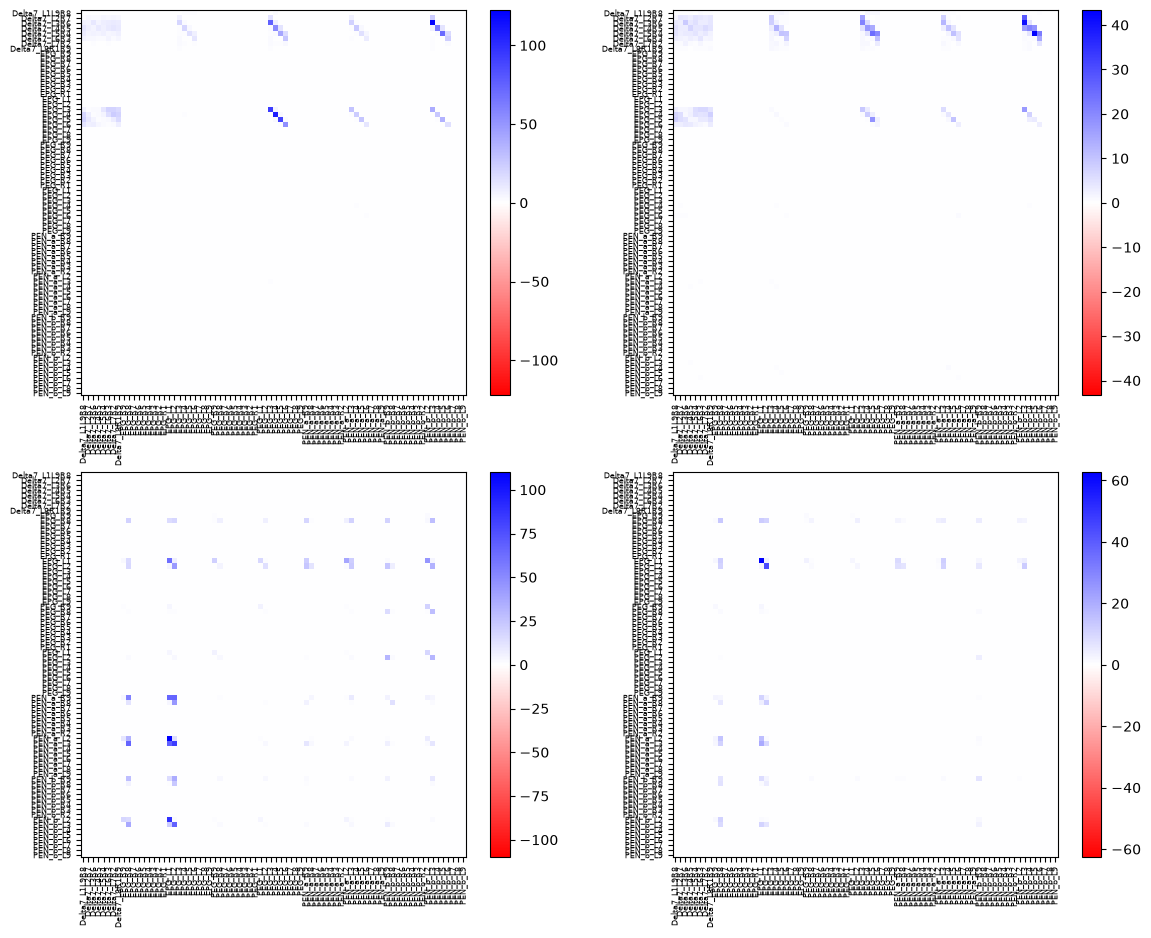

In [5]:
W_sample_mean_conn = extrapolator.group(W_sample)
W_sample_std_conn = np.sqrt(extrapolator.group_var(W_sample, W_sample_mean_conn))

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 11))
plot_grouped_weights(W_sample_mean_conn[0,:,:], grouped_labels, ax=ax1)
plot_grouped_weights(W_sample_std_conn[0,:,:], grouped_labels, ax=ax2)
plot_grouped_weights(W_sample_mean_conn[1,:,:], grouped_labels, ax=ax3)
plot_grouped_weights(W_sample_std_conn[1,:,:], grouped_labels, ax=ax4)
plt.show()

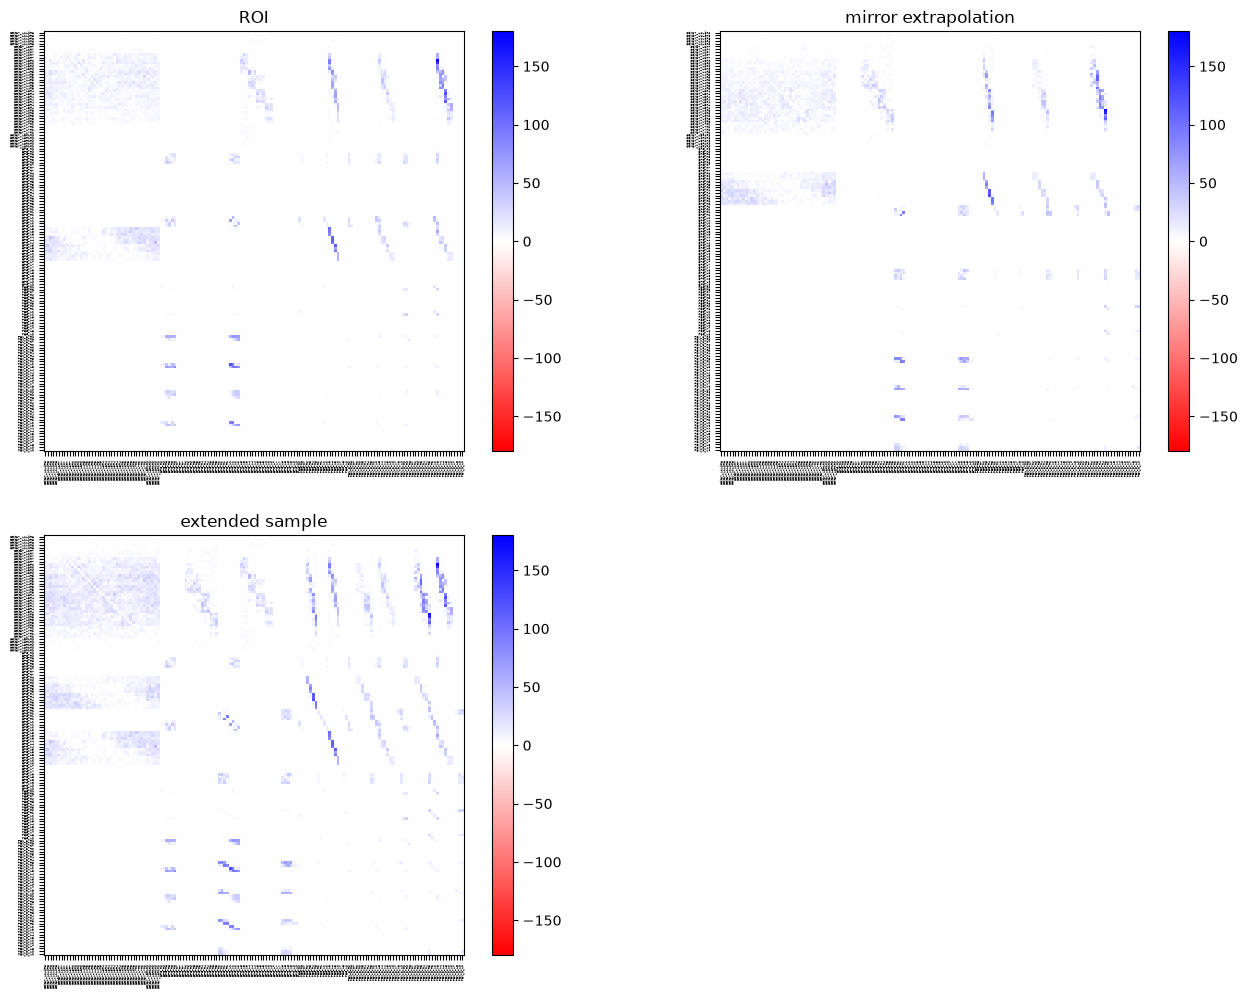

In [10]:
mirror_map = pl.read_csv("data/input/fly-cells-mirror.csv").with_row_index()
W_mirrored = np.zeros_like(W_sample)

for r in range(len(extrapolator.rois)):
    for i, (pre_type, pre_subtype, pre_indices) in enumerate(extrapolator.grouped.select("type", "subtype", "indices").rows()):
        for j, (post_type, post_subtype, post_indices) in enumerate(extrapolator.grouped.select("type", "subtype", "indices").rows()):
            count = len(pre_indices) * len(post_indices)
            if np.array_equal(pre_indices, post_indices):
                count -= len(pre_indices)
            if count <= 0:
                continue

            k = mirror_map.filter(type = pre_type, mirrored_subtype = pre_subtype)["index"][0]
            l = mirror_map.filter(type = post_type, mirrored_subtype = post_subtype)["index"][0]
            
            W_mirrored[np.ix_([r], pre_indices, post_indices)] = np.maximum(0, np.random.normal(loc=W_sample_mean_conn[r, k, l], scale=W_sample_std_conn[r, k, l], size=(len(pre_indices), len(post_indices))))

W_mirrored[0,...][np.eye(W_mirrored.shape[1], dtype=bool)] = 0
W_mirrored[1,...][np.eye(W_mirrored.shape[1], dtype=bool)] = 0
W_sample_extended = W_mirrored + W_sample

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
norm = CenteredNorm(vcenter=0)
ax1.set_title("ROI")
plot_weights(W_sample.sum(0), cell_labels, ax=ax1, norm=norm)
ax2.set_title("mirror extrapolation")
plot_weights(W_mirrored.sum(0), cell_labels, ax=ax2, norm=norm)
ax3.set_title("extended sample")
plot_weights(W_sample_extended.sum(0), cell_labels, ax=ax3, norm=norm)
ax4.remove()

plt.show()

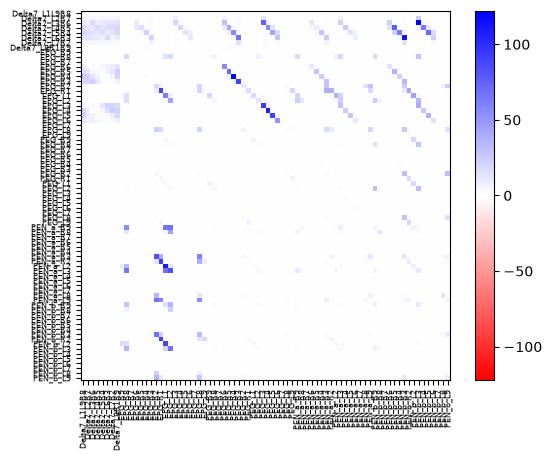

In [11]:
W_sample_extended_mean_conn = extrapolator.group(W_sample_extended)

plot_grouped_weights(W_sample_extended_mean_conn.sum(0), grouped_labels)
plt.show()

In [29]:
from scipy.optimize import least_squares, minimize, Bounds

x0 = extrapolator.init_theta()
x0 = result.x
result = least_squares(lambda theta: (extrapolator.extrapolate(theta, SAMPLE) - W_sample_mean_conn).flatten(), jac=lambda theta: extrapolator.jacobian_extrapolate(theta, SAMPLE), x0 = x0, bounds=extrapolator.theta_bounds(), verbose=2, ftol=1e-7, x_scale="jac")
#result = least_squares(lambda theta: W_norm.flatten() * (extrapolator.extrapolate(theta, SAMPLE) - W_grouped_sample).flatten(), jac=lambda theta: jac_normalization @ extrapolator.jacobian_extrapolate(theta, SAMPLE), x0 = extrapolator.init_theta(), bounds=extrapolator.theta_bounds(), verbose=2, ftol=1e-5)
#result = least_squares(lambda theta: (extrapolator.extrapolate(theta, SAMPLE) - W_grouped_sample).flatten(), x0 = extrapolator.init_theta(), bounds=extrapolator.theta_bounds(), verbose=2, ftol=1e-3)
#result = minimize(lambda theta: np.sum((extrapolator.extrapolate(theta, SAMPLE) - W_grouped_sample).flatten()**2), x0 = extrapolator.init_theta(), bounds=Bounds(lb=0), method="Nelder-Mead")
parameters = result.x

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.5030e+04                                    2.31e+02    
       1             14         1.5030e+04      6.59e-05       5.04e-04       6.30e+01    
`ftol` termination condition is satisfied.
Function evaluations 14, initial cost 1.5030e+04, final cost 1.5030e+04, first-order optimality 6.30e+01.


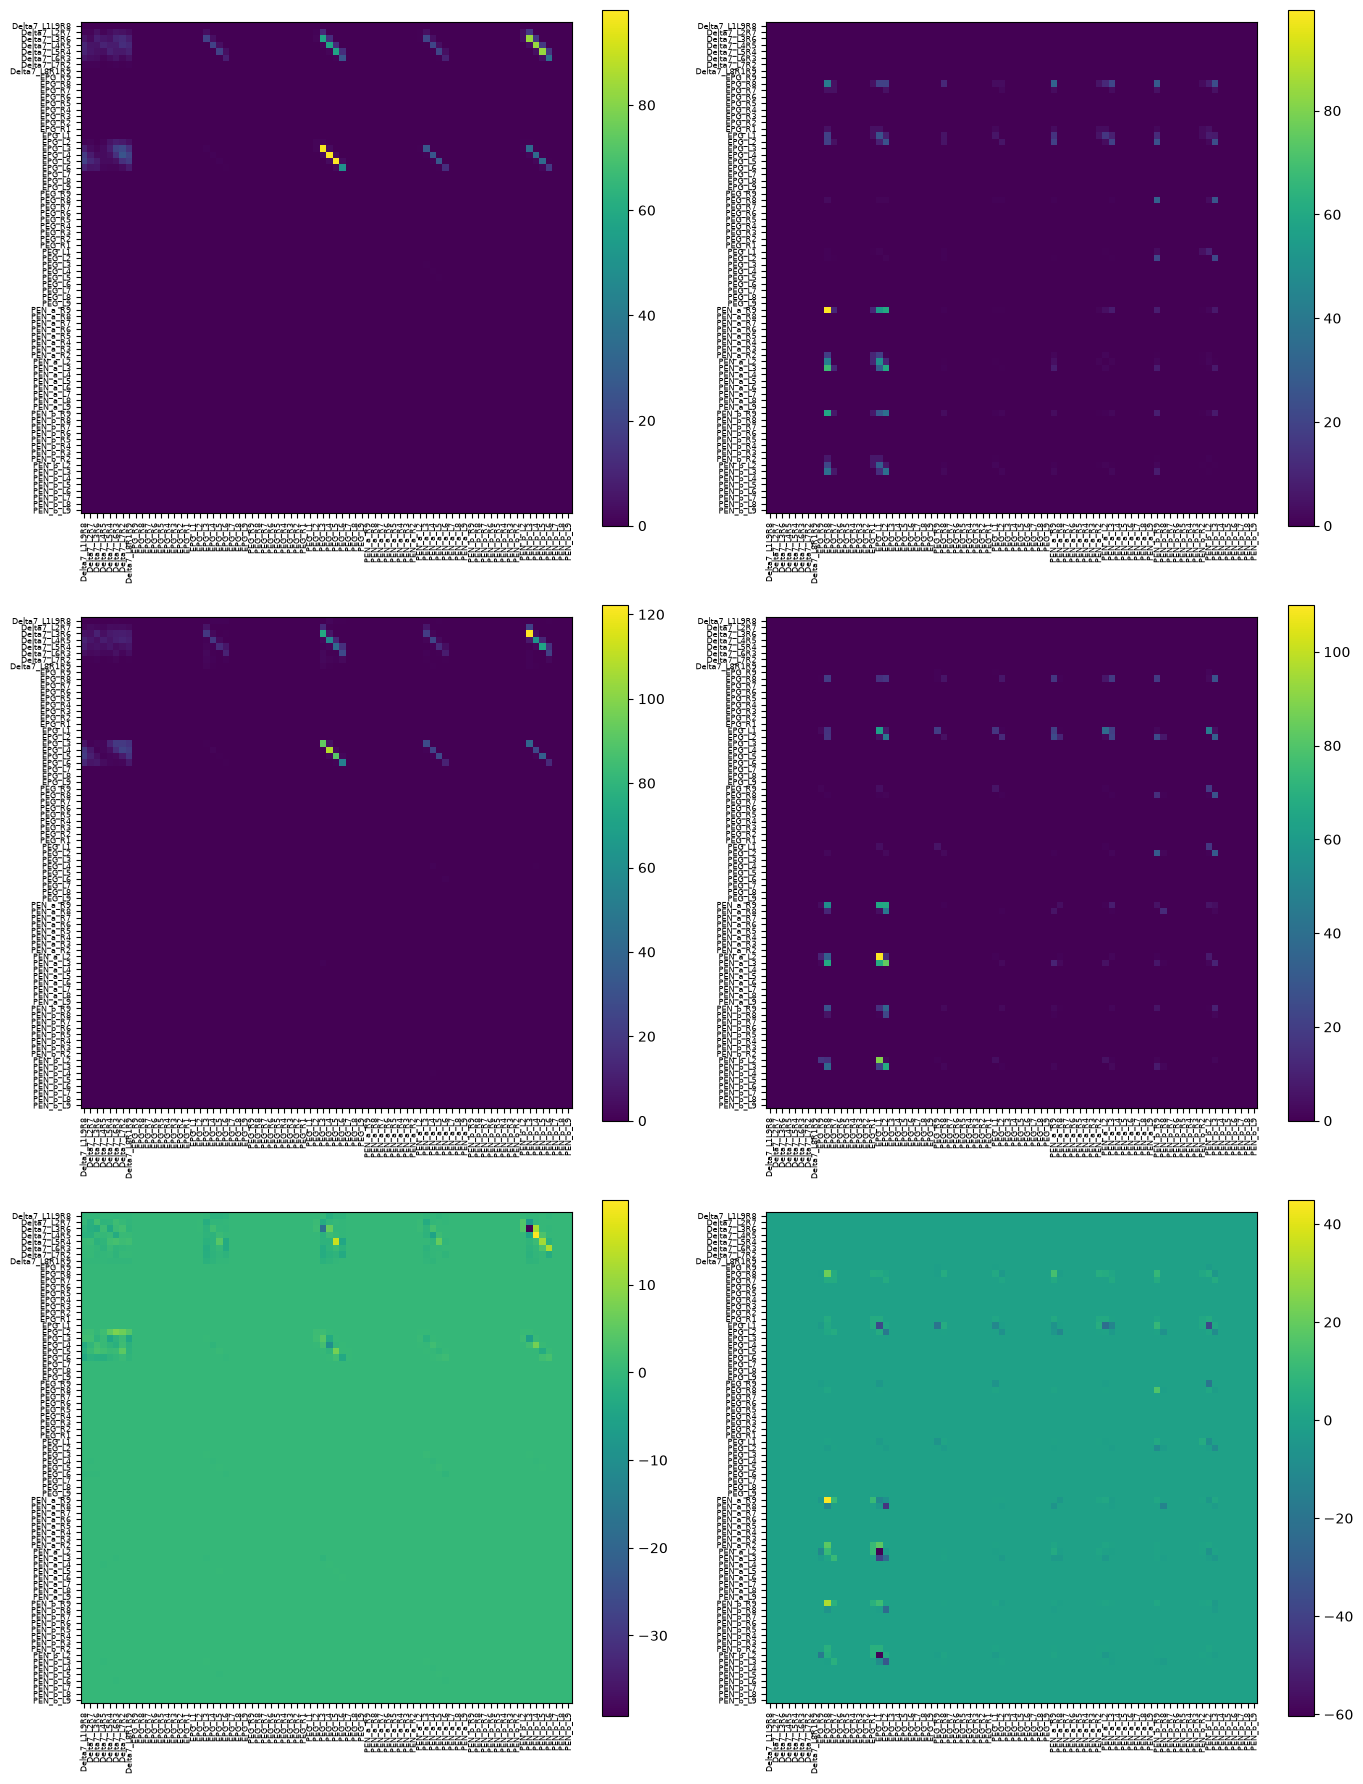

In [38]:
W_extrapolated_mean_conn_sample = extrapolator.extrapolate(parameters, SAMPLE)

np.save("data/fly-extrapolated-sample-mean.npy", W_extrapolated_mean_conn_sample)
np.save("data/fly-sample-mean.npy", W_sample_mean_conn)

fig, axes = plt.subplots(3, 2, figsize=(14, 18))
plot_grouped_weights(W_extrapolated_mean_conn_sample[0,...], grouped_labels, ax=axes[0][0])
plot_grouped_weights(W_extrapolated_mean_conn_sample[1,...], grouped_labels, ax=axes[0][1])
plot_grouped_weights(W_sample_mean_conn[0,...], grouped_labels, ax=axes[1][0])
plot_grouped_weights(W_sample_mean_conn[1,...], grouped_labels, ax=axes[1][1])
plot_grouped_weights(W_extrapolated_mean_conn_sample[0,...] - W_sample_mean_conn[0,...], grouped_labels, ax=axes[2][0])
plot_grouped_weights(W_extrapolated_mean_conn_sample[1,...] - W_sample_mean_conn[1,...], grouped_labels, ax=axes[2][1])
plt.tight_layout()
plt.show()

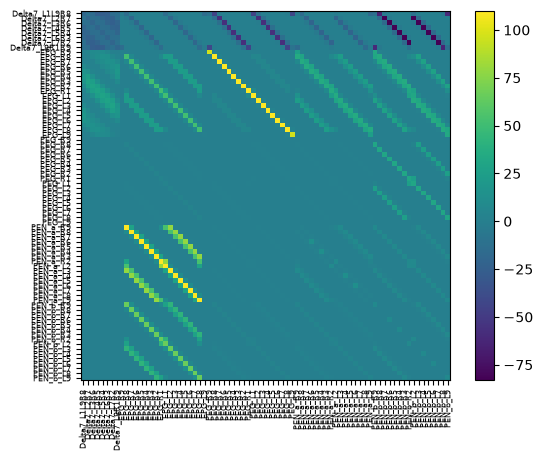

In [37]:
W_extrapolated_mean_conn = extrapolator.extrapolate(parameters, COLUMNS)
#plot_grouped_weights(W_extrapolated_mean_conn.sum(0), extrapolator.grouped["type"] + "_" + extrapolator.grouped["subtype"])

W_extrapolated_mean_conn_signed = W_extrapolated_mean_conn.copy()
W_extrapolated_mean_conn_signed[:,extrapolator.grouped["type"] == "Delta7",:] *= -1
np.save("data/fly-mean-conn.npy", W_extrapolated_mean_conn_signed)
plot_grouped_weights(W_extrapolated_mean_conn_signed.sum(0), extrapolator.grouped["type"] + "_" + extrapolator.grouped["subtype"])

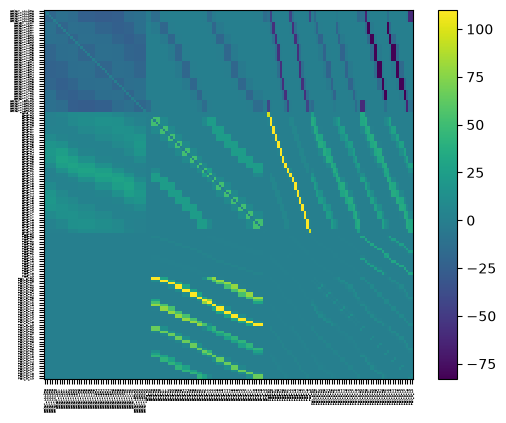

In [32]:
W_extrapolated = np.zeros((len(ROIS), len(CELLS), len(CELLS)))

for ti, ii in enumerate(extrapolator.grouped["indices"]):
    for tj, jj in enumerate(extrapolator.grouped["indices"]):
        #count = len(ii) * len(jj)
        #if ti == tj:
        #    count -= ti
        #if count <= 0:
        #    continue
        for r in range(len(ROIS)):
            W_extrapolated[np.ix_([r], ii, jj)] = W_extrapolated_mean_conn[r,ti,tj]

        if ti == tj:
            W_extrapolated[:, ii, jj] = 0

#plot_weights(W_extrapolated[0,:,:] + W_extrapolated[1,:,:], cell_labels)
#np.save("../data/connectomes/final/fly-extrapolated-mean.npy", W_full)
# 
W_extrapolated_signed = W_extrapolated.copy()
W_extrapolated_signed[:,CELLS["type"] == "Delta7",:] *= -1

np.save("data/fly-extrapolated-full.npy", W_extrapolated_signed)
plot_weights(W_extrapolated_signed.sum(0), cell_labels)


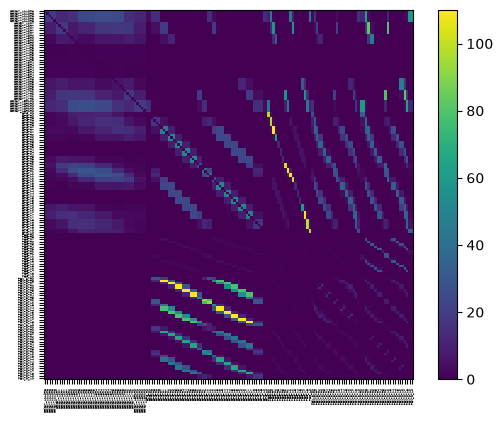

In [34]:
W_extrapolated_oos_mean_conn = extrapolator.extrapolate(parameters, set(COLUMNS) - set(EXTENDED_SAMPLE))
W_extrapolated_oos = np.zeros((len(ROIS), len(CELLS), len(CELLS)))

for ti, ii in enumerate(extrapolator.grouped["indices"]):
    for tj, jj in enumerate(extrapolator.grouped["indices"]):
        for r in range(len(ROIS)):
            W_extrapolated_oos[np.ix_([r], ii, jj)] = W_extrapolated_oos_mean_conn[r,ti,tj]

        if ti == tj:
            W_extrapolated_oos[:, ii, jj] = 0

plot_weights(W_extrapolated_oos.sum(0), cell_labels)

global std: 0.38925050390087085


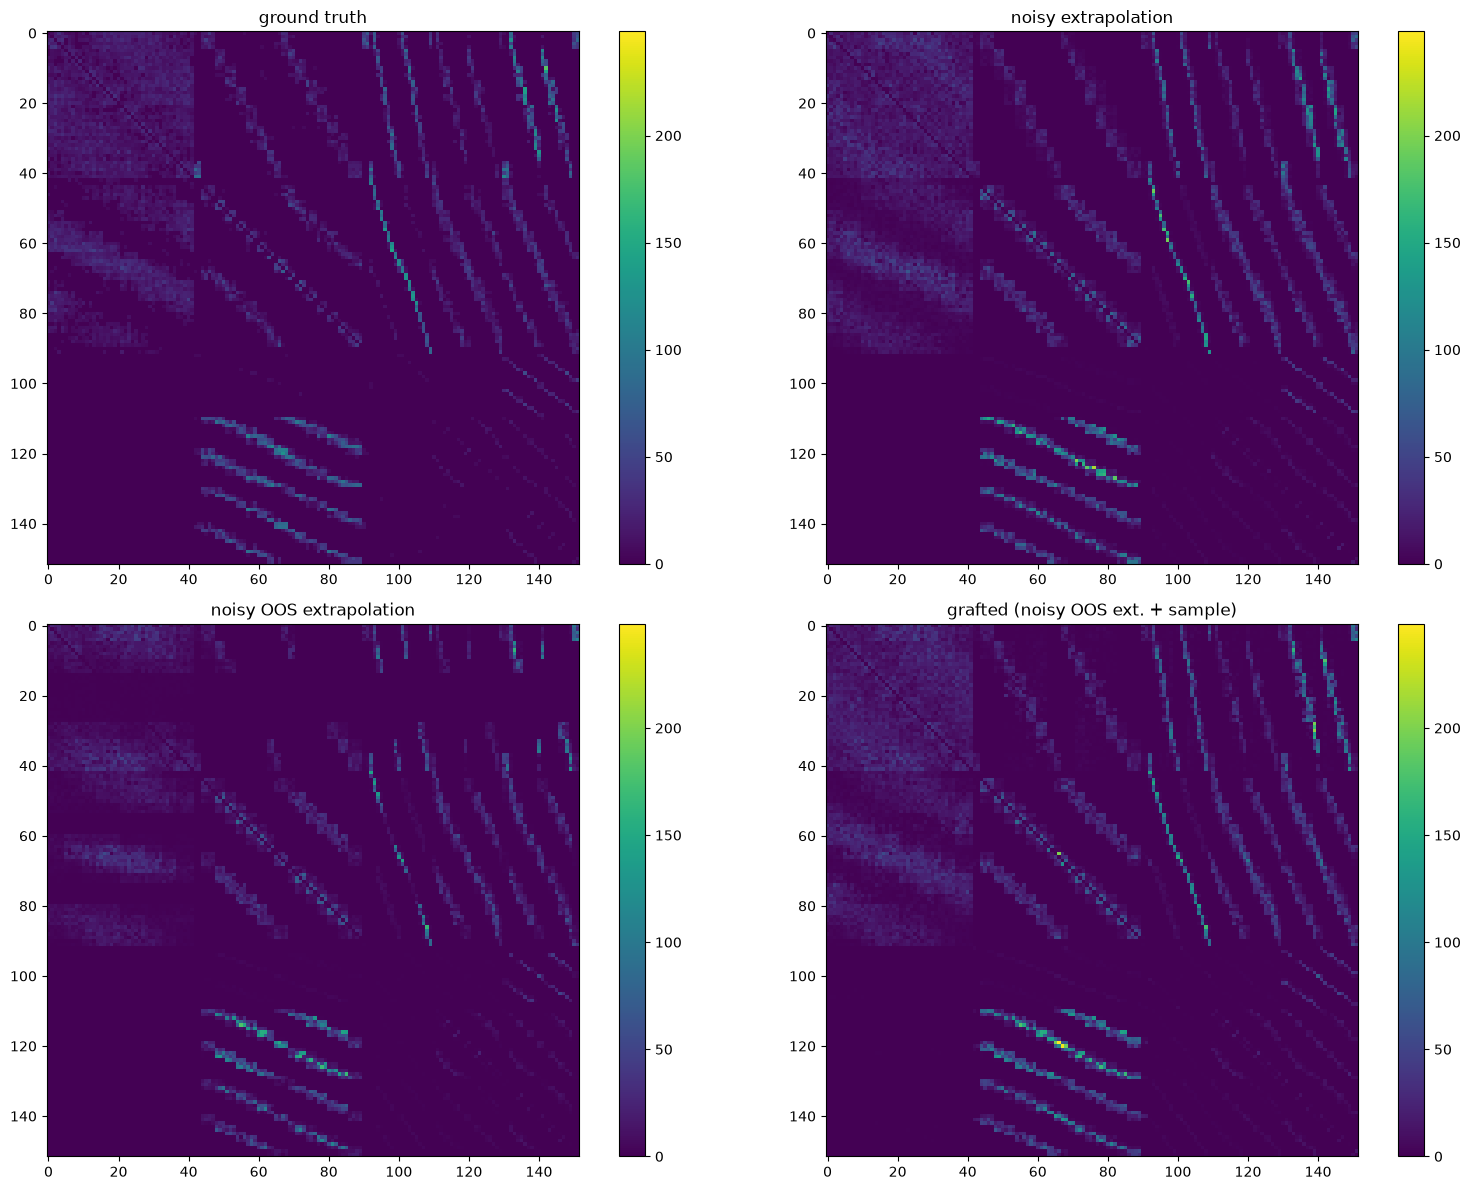

In [35]:
non_zero = (W_extrapolated > 10) #& (Ws > 10)
std = np.std(W_sample[non_zero] / W_extrapolated[non_zero])
print(f"global std: {std}")

W_extrapolated_noisy = np.maximum(0, W_extrapolated * np.random.normal(1, std, W_extrapolated.shape))
W_extrapolated_oos_noisy = np.maximum(0, W_extrapolated_oos * np.random.normal(1, std, W_extrapolated_oos.shape))
W_extrapolated_grafted = W_extrapolated_oos_noisy + W_sample_extended

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
norm = plt.Normalize(vmax=np.max([np.max(W_ground), np.max(W_extrapolated_noisy), np.max(W_extrapolated_oos_noisy), np.max(W_extrapolated_grafted)]))
ax1.set_title("ground truth")
c = ax1.imshow(np.sum(W_ground, axis=0), interpolation="nearest", norm=norm)
plt.colorbar(c)
ax2.set_title("noisy extrapolation")
c = ax2.imshow(np.sum(W_extrapolated_noisy, axis=0), interpolation="nearest", norm=norm)
plt.colorbar(c)
ax3.set_title("noisy OOS extrapolation")
c = ax3.imshow(np.sum(W_extrapolated_oos_noisy, axis=0), interpolation="nearest", norm=norm)
plt.colorbar(c)
ax4.set_title("grafted (noisy OOS ext. + sample)")
c = ax4.imshow(np.sum(W_extrapolated_grafted, axis=0), interpolation="nearest", norm=norm)
plt.colorbar(c)
plt.tight_layout()
plt.show()

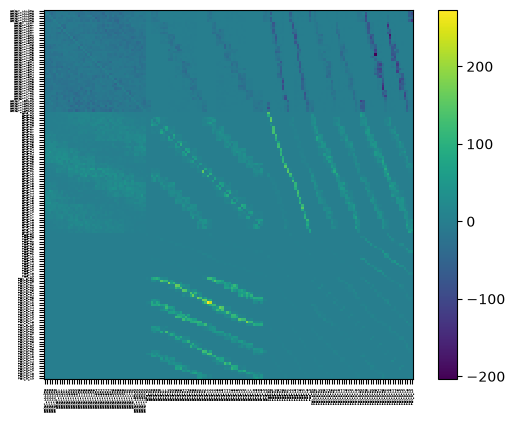

In [17]:
W_extrapolated_grafted_signed = W_extrapolated_grafted.copy()
W_extrapolated_grafted_signed[:,CELLS["type"] == "Delta7",:] *= -1

np.save("data/fly-grafted-full.npy", W_extrapolated_grafted_signed)
plot_weights(W_extrapolated_grafted_signed.sum(0), cell_labels)


In [7]:
W_extrapolated_grafted = np.abs(np.load("data/fly-grafted-full.npy"))

115.0


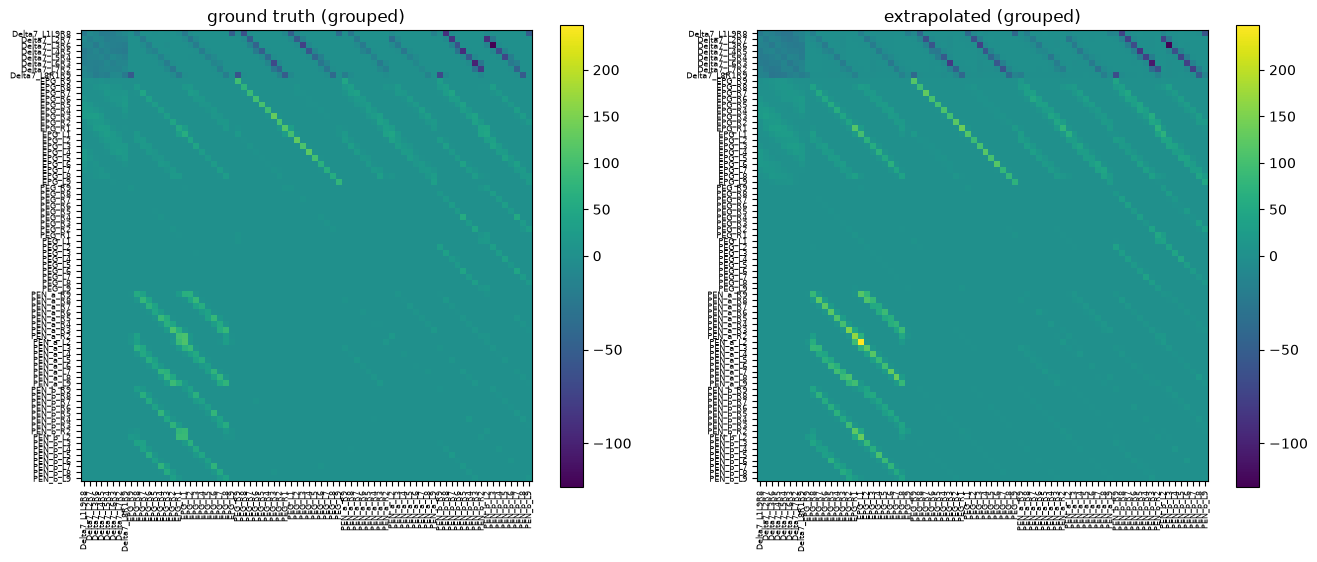

In [13]:
from matplotlib.colors import TwoSlopeNorm

W_ground_mean_input = extrapolator.mean_to_mean_input(extrapolator.group(W_ground))
W_extrapolated_mean_input = extrapolator.mean_to_mean_input(extrapolator.group(W_extrapolated_grafted))

W_ground_mean_input_signed = W_ground_mean_input.copy()
W_ground_mean_input_signed[:,:8,:] *= -1
W_extrapolated_mean_input_signed = W_extrapolated_mean_input.copy()
W_extrapolated_mean_input_signed[:,:8,:] *= -1
print(np.max(W_ground_mean_input_signed))

#np.save("data/fly-truth.npy", W_ground_mean_input_signed)
#np.save("data/fly-grafted.npy", W_extrapolated_mean_input_signed)

norm = TwoSlopeNorm(
    vcenter = 0,
    vmin = np.minimum(np.min(W_ground_mean_input_signed), np.min(W_extrapolated_mean_input_signed)),
    vmax = np.maximum(np.max(W_ground_mean_input_signed), np.max(W_extrapolated_mean_input_signed)),
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.set_title("ground truth (grouped)")
plot_grouped_weights(W_ground_mean_input_signed.sum(0), grouped_labels, ax=ax1, norm=norm)
ax2.set_title("extrapolated (grouped)")
plot_grouped_weights(W_extrapolated_mean_input_signed.sum(0), grouped_labels, ax=ax2, norm=norm)
plt.show()

In [15]:
from scipy.optimize import least_squares, minimize, Bounds

W_ground_mean_conn = extrapolator.group(W_ground)

#x0 = extrapolator.init_theta()
x0 = result.x
result = least_squares(lambda theta: (extrapolator.extrapolate(theta, COLUMNS) - W_ground_mean_conn).flatten(), jac=lambda theta: extrapolator.jacobian_extrapolate(theta, COLUMNS), x0 = x0, bounds=extrapolator.theta_bounds(), verbose=2, ftol=1e-7, x_scale="jac")
parameters_full = result.x

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.1815e+04                                    9.29e+03    
       1             12         4.1815e+04      4.86e-04       1.39e-04       9.29e+03    
`ftol` termination condition is satisfied.
Function evaluations 12, initial cost 4.1815e+04, final cost 4.1815e+04, first-order optimality 9.29e+03.


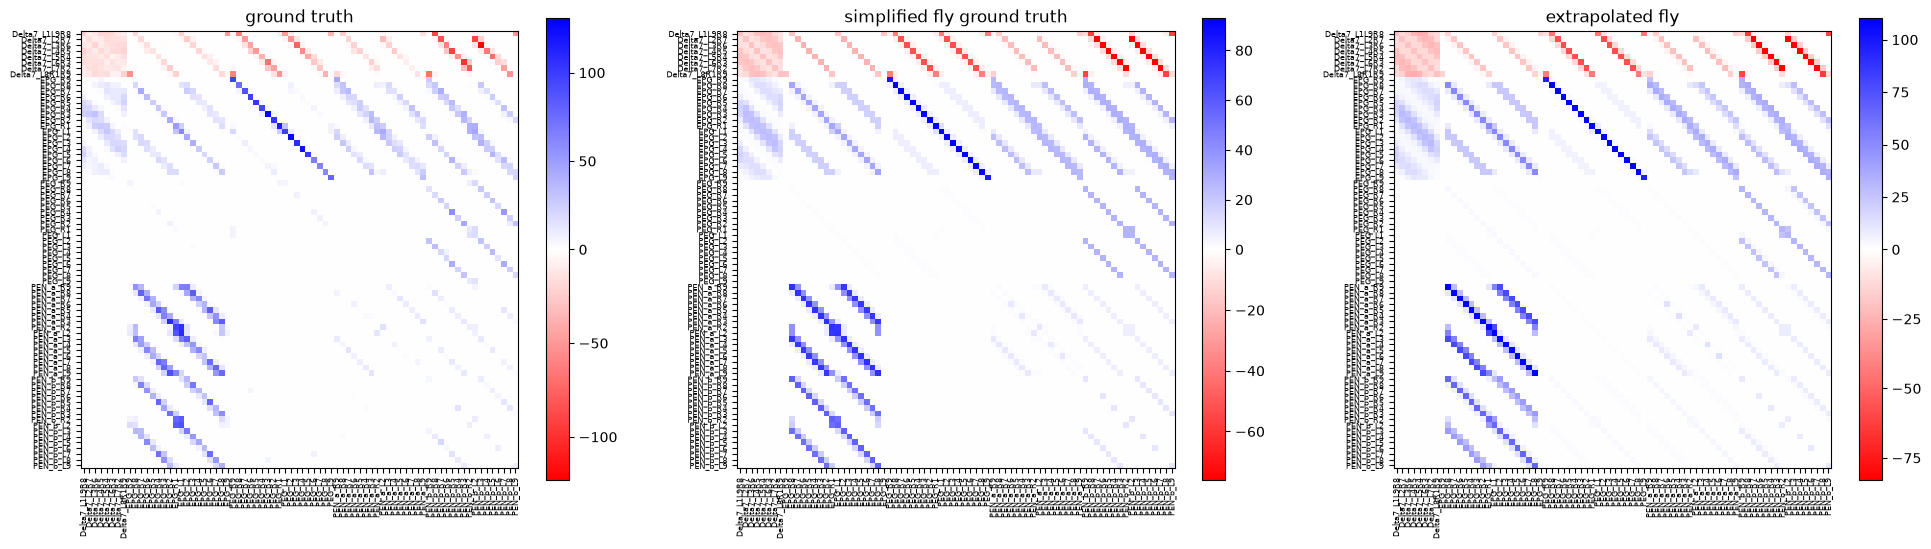

In [27]:
W_ground_simplified = extrapolator.extrapolate(parameters_full, COLUMNS)

W_ground_mean_conn_signed = W_ground_mean_conn.copy()
W_ground_mean_conn_signed[:,extrapolator.grouped["type"] == "Delta7",:] *= -1

W_ground_simplified_signed = W_ground_simplified.copy()
W_ground_simplified_signed[:,extrapolator.grouped["type"] == "Delta7",:] *= -1
np.save("data/fly-truth-simplified.npy", W_ground_simplified_signed)

W_extrapolated_mean_conn_signed = np.load("data/fly-mean-conn.npy")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))
ax1.set_title("ground truth")
plot_grouped_weights(W_ground_mean_conn_signed.sum(0), grouped_labels, ax=ax1)
ax2.set_title("simplified fly ground truth")
plot_grouped_weights(W_ground_simplified_signed.sum(0), grouped_labels, ax=ax2)
ax3.set_title("extrapolated fly")
plot_grouped_weights(W_extrapolated_mean_conn_signed.sum(0), grouped_labels, ax=ax3)
plt.savefig("results/extrapolation-full-comparison.pdf")
plt.show()